In [1]:
# FP Growth

In [2]:
# Step 1: Import required libraries
# TODO:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [3]:
#!pip install mlxtend

In [4]:
# Step 2: Define or load transaction data for this batch
# TODO:
# Create or load one transaction list for the current batch.
# Prefer a different context from the previous exam batch.
# Example structure:
transactions = [
    ["Milk", "Bread", "Eggs"],
    ["Milk", "Bread"],
    ["Milk", "Eggs"],
    ["Bread", "Butter"],
    ["Milk", "Butter"],
    ["Bread", "Eggs"],
    ["Milk", "Bread", "Butter"],
    ["Eggs", "Butter"],
    ["Milk", "Bread", "Eggs", "Butter"],
    ["Bread"]
]


In [5]:
# Step 3: Convert transactions into basket / one-hot encoded format
# TO DO 
# te = ...
# te_array = ...
# df_trans = ...
# display(df_trans.head())
tran = TransactionEncoder() 
te_array = tran.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_array, columns=tran.columns_)
print("Encoded Transaction Data:")
print(df_trans.head())

Encoded Transaction Data:
   Bread  Butter   Eggs   Milk
0   True   False   True   True
1   True   False  False   True
2  False   False   True   True
3   True    True  False  False
4  False    True  False   True


In [6]:
# Step 4: Apply FP-Growth

# Suggested:
# min_sup = 0.25
# TODO:
# min_sup = ...
# frequent_itemsets = ...
# sort the frequent itemsets by support in descending order
# display the result

min_sup = 0.25
frequent_itemsets = fpgrowth(df_trans, min_support=min_sup, use_colnames=True)
# Sort by support
frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)
print("Frequent Itemsets:")
print(frequent_itemsets)

Frequent Itemsets:
   support                    itemsets
0      0.7          frozenset({Bread})
1      0.6           frozenset({Milk})
2      0.5           frozenset({Eggs})
3      0.5         frozenset({Butter})
4      0.4    frozenset({Milk, Bread})
5      0.3     frozenset({Milk, Eggs})
6      0.3    frozenset({Eggs, Bread})
7      0.3  frozenset({Butter, Bread})
8      0.3   frozenset({Butter, Milk})


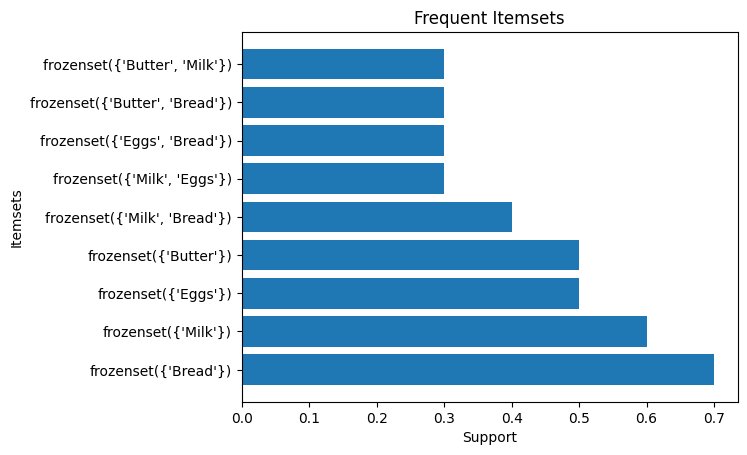

In [9]:
# Step 5: Visualize top frequent itemsets
# TODO:
# 1. Select top itemsets
# 2. Convert itemsets to readable strings
# 3. Create a bar plot of support values
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

plt.barh(frequent_itemsets['itemsets'].astype(str), frequent_itemsets['support'])
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.title("Frequent Itemsets")
plt.show()

In [11]:
# Step 6: Generate association rules (optional)
# TODO:
# rules = association_rules(frequent_itemsets, metric="confidence", min_threshol
# display useful columns such as:
# antecedents, consequents, support, confidence, lift

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


,antecedents,consequents,support,confidence,lift
0,frozenset({Milk}),frozenset({Bread}),0.4,0.666667,0.952381
1,frozenset({Bread}),frozenset({Milk}),0.4,0.571429,0.952381
2,frozenset({Milk}),frozenset({Eggs}),0.3,0.500000,1.000000
3,frozenset({Eggs}),frozenset({Milk}),0.3,0.600000,1.000000
4,frozenset({Eggs}),frozenset({Bread}),0.3,0.600000,0.857143
5,frozenset({Butter}),frozenset({Bread}),0.3,0.600000,0.857143
6,frozenset({Butter}),frozenset({Milk}),0.3,0.600000,1.000000
7,frozenset({Milk}),frozenset({Butter}),0.3,0.500000,1.000000


In [12]:
# Optional Challenge
# Compare the output for two different support thresholds
# and comment on the change in number of itemsets and rules
# TODO:
# min_sup_values = [0.2, 0.35]
# run FP-Growth for each value
# compare outputs

min_sup_values = [0.2, 0.35]

for sup in min_sup_values:
    fi = fpgrowth(df_trans, min_support=sup, use_colnames=True)
    print(f"\nMin Support = {sup}")
    print("Number of itemsets:", len(fi))


Min Support = 0.2
Number of itemsets: 12

Min Support = 0.35
Number of itemsets: 5


In [13]:
# Student Observation Section
# Write your observations here:

# 1) Which single items appear most frequently?
# ANS: Bread appears most frequently

# 2) Which item combinations occur together often?
# ANS: Milk and Bread item combination occurs together often

# 3) Which rule has high confidence or high lift?
# ANS: Purchase of milk influence purchase of bread has high confidence and high lift

# 4) What is the effect of reducing or increasing minimum support?
# ANS:reducing minimum support allows the algorithm to find more frequent itemsets
#     and increasing minimum support filter out more item resulting in smaller trees